In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

print("All libraries imported successfully")

All libraries imported successfully


In [2]:
# Load data
df = pd.read_csv('../data/upi_india_monthly_enriched.csv')

# Convert Date column to proper date format
df['Date'] = pd.to_datetime(df['Date'])

# Remove pre-launch zero rows (Jan–Jul 2016, UPI launched August 2016)
df = df[df['Volume_Mn'] > 0].reset_index(drop=True)

# Add average transaction value column (Value in Crore / Volume in Mn = ₹ per transaction)
df['Avg_Txn_Value'] = (df['Value_Cr'] / df['Volume_Mn']) * 100

# Confirm
print("Shape:", df.shape)
print("Date range:", df['Date'].min().strftime('%b %Y'), "to", df['Date'].max().strftime('%b %Y'))
print("Columns:", list(df.columns))
print("\nFirst 3 rows:")
df.head(3)

Shape: (113, 19)
Date range: Aug 2016 to Dec 2025
Columns: ['Date', 'Year', 'Month_Num', 'Month_Name', 'Financial_Year', 'Volume_Mn', 'Value_Cr', 'Volume_MoM_%', 'Value_MoM_%', 'Volume_YoY_%', 'Value_YoY_%', 'Month_Sin', 'Month_Cos', 'Volume_RollMean_3M', 'Value_RollMean_3M', 'Is_Covid_Period', 'Is_Festive_Season', 'Event_Code', 'Avg_Txn_Value']

First 3 rows:


,Date,Year,Month_Num,Month_Name,Financial_Year,Volume_Mn,Value_Cr,Volume_MoM_%,Value_MoM_%,Volume_YoY_%,Value_YoY_%,Month_Sin,Month_Cos,Volume_RollMean_3M,Value_RollMean_3M,Is_Covid_Period,Is_Festive_Season,Event_Code,Avg_Txn_Value
0,2016-08-01,2016,8,August,FY16-17,0.093000,3.100000,inf,inf,NaN,NaN,-0.866025,-5.000000e-01,0.031000,1.033333,0,0,0,3333.333333
1,2016-09-01,2016,9,September,FY16-17,1.122667,313.533333,1107.17,10013.98,NaN,NaN,-1.000000,-1.836970e-16,0.405222,105.544444,0,0,0,27927.553444
2,2016-10-01,2016,10,October,FY16-17,2.152333,623.966667,91.72,99.01,NaN,NaN,-0.866025,5.000000e-01,1.122667,313.533333,0,1,0,28990.243147


In [3]:
# Year-wise aggregation
yearly = df.groupby('Year').agg(
    Total_Volume_Mn=('Volume_Mn', 'sum'),
    Total_Value_Cr=('Value_Cr', 'sum'),
    Avg_Txn_Value=('Avg_Txn_Value', 'mean')
).reset_index()

# Calculate Year-over-Year growth %
yearly['Volume_YoY_Growth'] = yearly['Total_Volume_Mn'].pct_change() * 100
yearly['Value_YoY_Growth'] = yearly['Total_Value_Cr'].pct_change() * 100

# Round everything
yearly = yearly.round(2)

print("Year-wise UPI Summary:")
yearly

Year-wise UPI Summary:


,Year,Total_Volume_Mn,Total_Value_Cr,Avg_Txn_Value,Volume_YoY_Growth,Value_YoY_Growth
0,2016,10.76,3119.83,23834.62,NaN,NaN
1,2017,339.28,61519.67,24286.61,3052.70,1871.89
2,2018,3744.17,596308.00,15706.09,1003.55,869.30
3,2019,11335.16,1875600.00,16510.16,202.74,214.54
4,2020,17930.00,3136000.00,17120.50,58.18,67.20
5,2021,39745.00,7318000.00,18466.11,121.67,133.35
6,2022,75005.00,12786000.00,17135.61,88.72,74.72
7,2023,120185.00,18321000.00,15285.05,60.24,43.29
8,2024,176450.00,25362500.00,14405.50,46.82,38.43
9,2025,231750.00,30533000.00,13198.80,31.34,20.39


In [4]:
# Save to output folder
df.to_csv('../output/upi_cleaned.csv', index=False)
df.to_excel('../output/upi_cleaned.xlsx', index=False)
yearly.to_csv('../output/upi_yearly_summary.csv', index=False)
yearly.to_excel('../output/upi_yearly_summary.xlsx', index=False)

print("Files saved successfully to output folder:")
print("  - upi_cleaned.csv / .xlsx")
print("  - upi_yearly_summary.csv / .xlsx")

Files saved successfully to output folder:
  - upi_cleaned.csv / .xlsx
  - upi_yearly_summary.csv / .xlsx


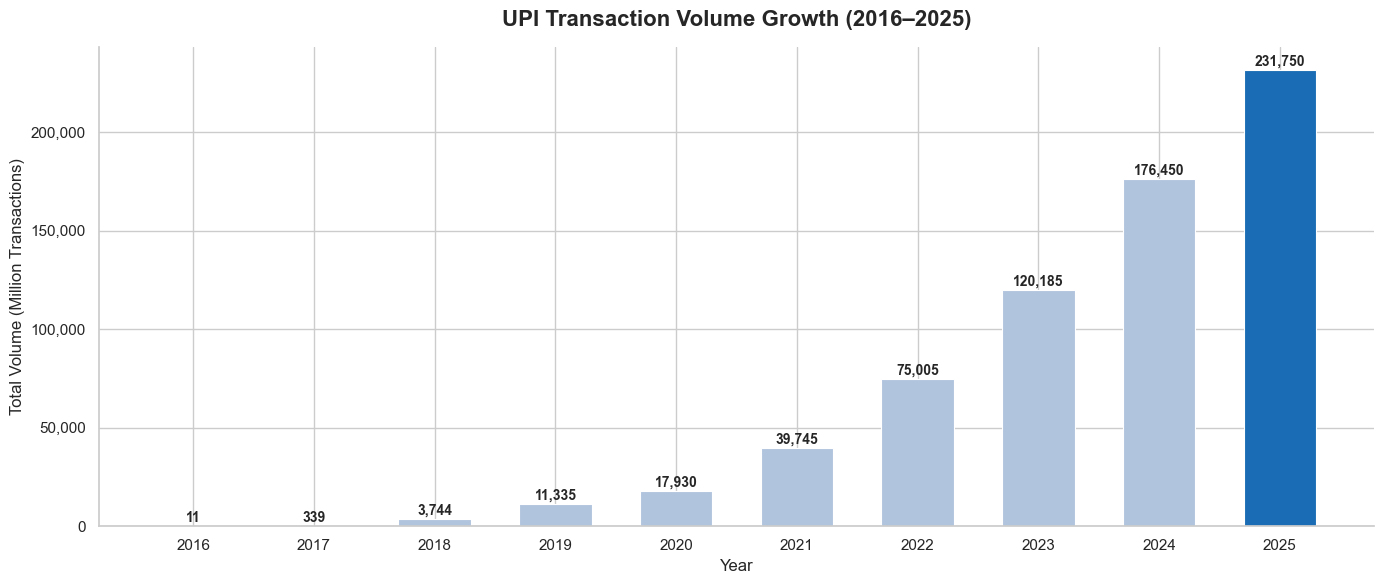

Chart 1 saved


In [5]:
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(yearly['Year'], yearly['Total_Volume_Mn'],
              color=['#b0c4de' if y != yearly['Year'].max() else '#1a6db5' for y in yearly['Year']],
              width=0.6, edgecolor='white', linewidth=0.8)

# Add value labels on top of each bar
for bar, val in zip(bars, yearly['Total_Volume_Mn']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('UPI Transaction Volume Growth (2016–2025)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Total Volume (Million Transactions)', fontsize=12)
ax.set_xticks(yearly['Year'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
sns.despine()
plt.tight_layout()
plt.savefig('../output/chart1_volume_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved")

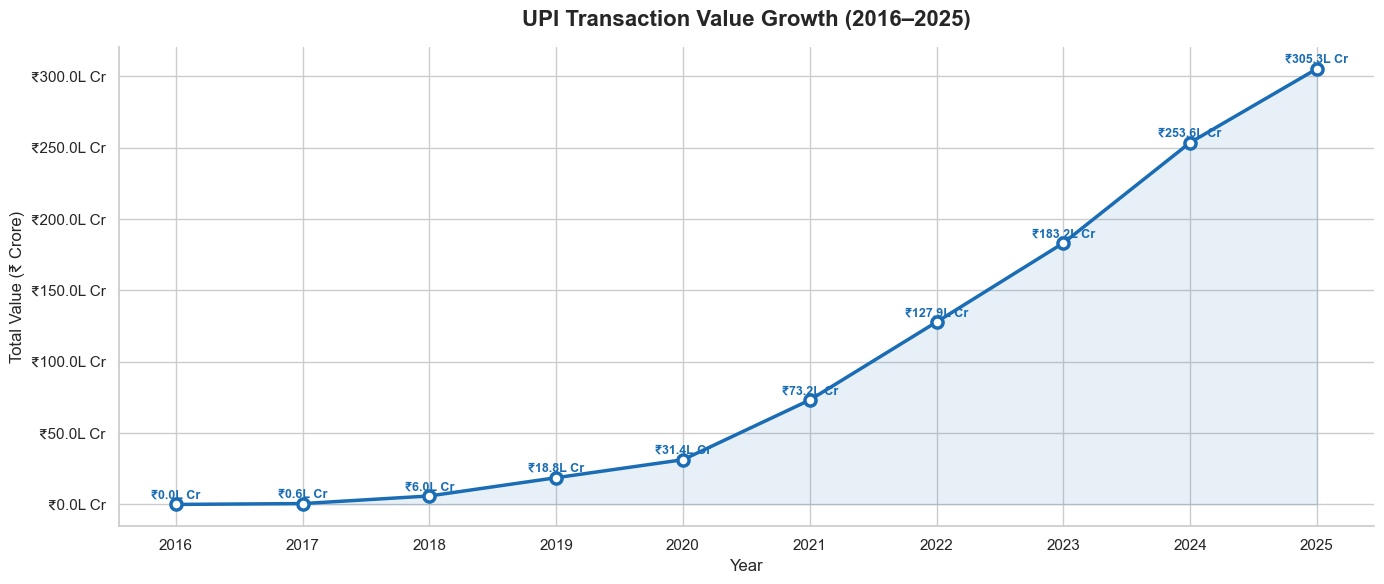

Chart 2 saved


In [6]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(yearly['Year'], yearly['Total_Value_Cr'],
        color='#1a6db5', linewidth=2.5, marker='o',
        markersize=8, markerfacecolor='white', markeredgewidth=2.5)

# Shade area under line
ax.fill_between(yearly['Year'], yearly['Total_Value_Cr'],
                alpha=0.1, color='#1a6db5')

# Add value labels
for _, row in yearly.iterrows():
    ax.text(row['Year'], row['Total_Value_Cr'] + 400000,
            f'₹{row["Total_Value_Cr"]/100000:.1f}L Cr',
            ha='center', fontsize=9, fontweight='bold', color='#1a6db5')

ax.set_title('UPI Transaction Value Growth (2016–2025)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Total Value (₹ Crore)', fontsize=12)
ax.set_xticks(yearly['Year'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/100000:.1f}L Cr'))
sns.despine()
plt.tight_layout()
plt.savefig('../output/chart2_value_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved")

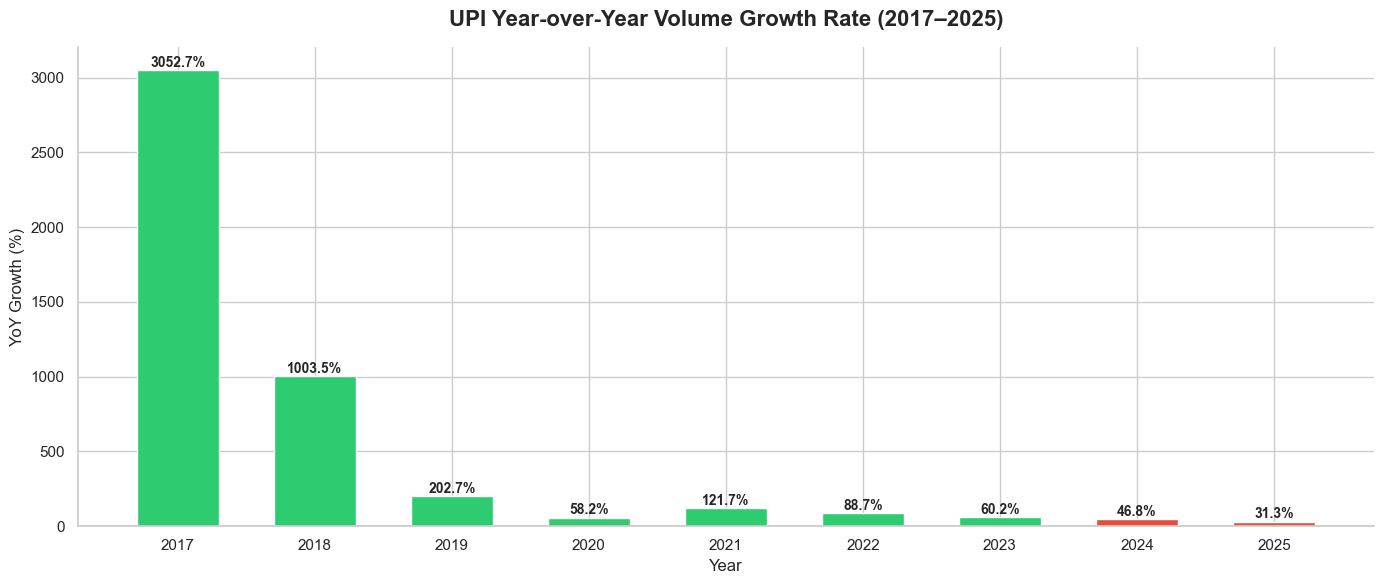

Chart 3 saved


In [7]:
# Drop 2016 as YoY doesn't apply for first year
yearly_yoy = yearly.dropna(subset=['Volume_YoY_Growth'])

fig, ax = plt.subplots(figsize=(14, 6))

colors = ['#e74c3c' if v < 50 else '#2ecc71' for v in yearly_yoy['Volume_YoY_Growth']]
bars = ax.bar(yearly_yoy['Year'], yearly_yoy['Volume_YoY_Growth'],
              color=colors, width=0.6, edgecolor='white')

for bar, val in zip(bars, yearly_yoy['Volume_YoY_Growth']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom',
            fontsize=10, fontweight='bold')

ax.set_title('UPI Year-over-Year Volume Growth Rate (2017–2025)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('YoY Growth (%)', fontsize=12)
ax.set_xticks(yearly_yoy['Year'])
ax.axhline(y=0, color='black', linewidth=0.8)
sns.despine()
plt.tight_layout()
plt.savefig('../output/chart3_yoy_growth.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved")

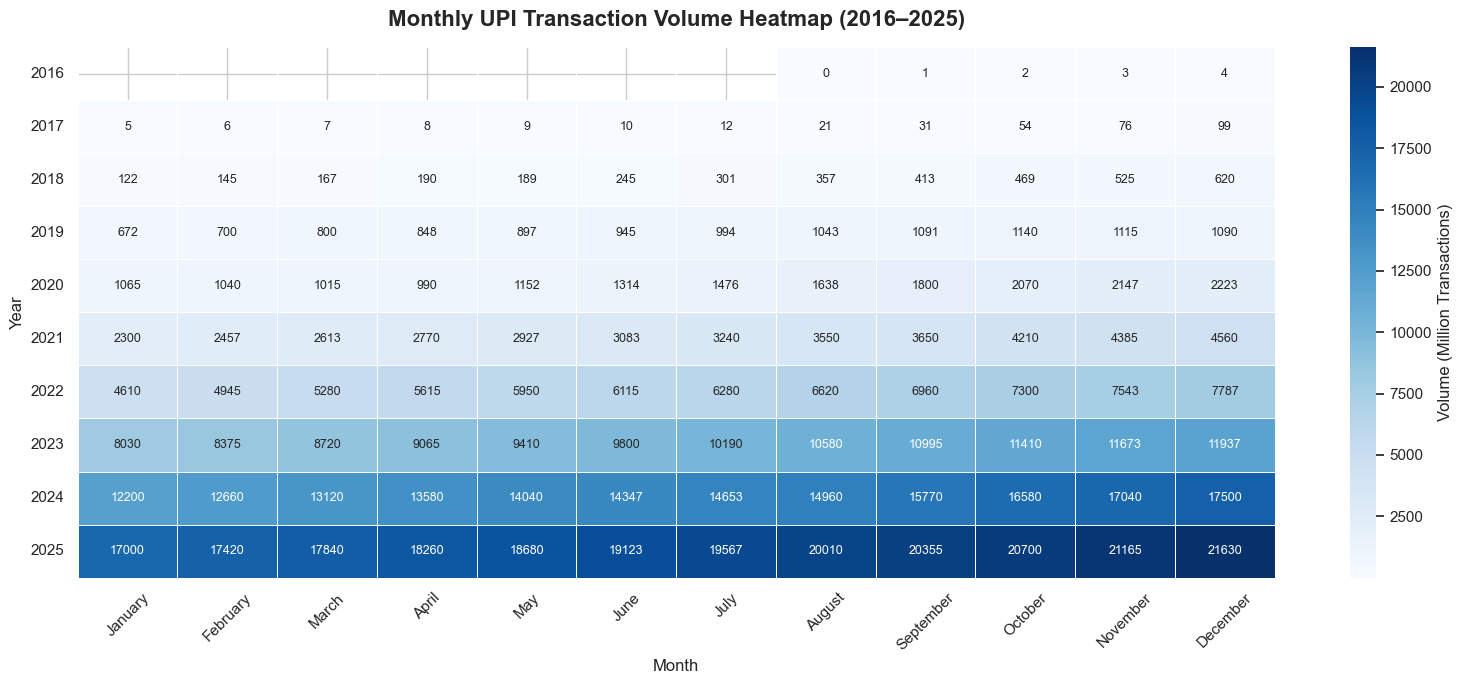

Chart 4 saved


In [8]:
# Pivot table: Year vs Month
pivot = df.pivot_table(values='Volume_Mn', index='Year', columns='Month_Name', aggfunc='sum')

# Reorder months correctly
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
pivot = pivot.reindex(columns=month_order)

fig, ax = plt.subplots(figsize=(16, 7))

sns.heatmap(pivot, annot=True, fmt='.0f', cmap='Blues',
            linewidths=0.5, linecolor='white',
            annot_kws={'size': 9}, ax=ax,
            cbar_kws={'label': 'Volume (Million Transactions)'})

ax.set_title('Monthly UPI Transaction Volume Heatmap (2016–2025)',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Year', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('../output/chart4_seasonality_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved")

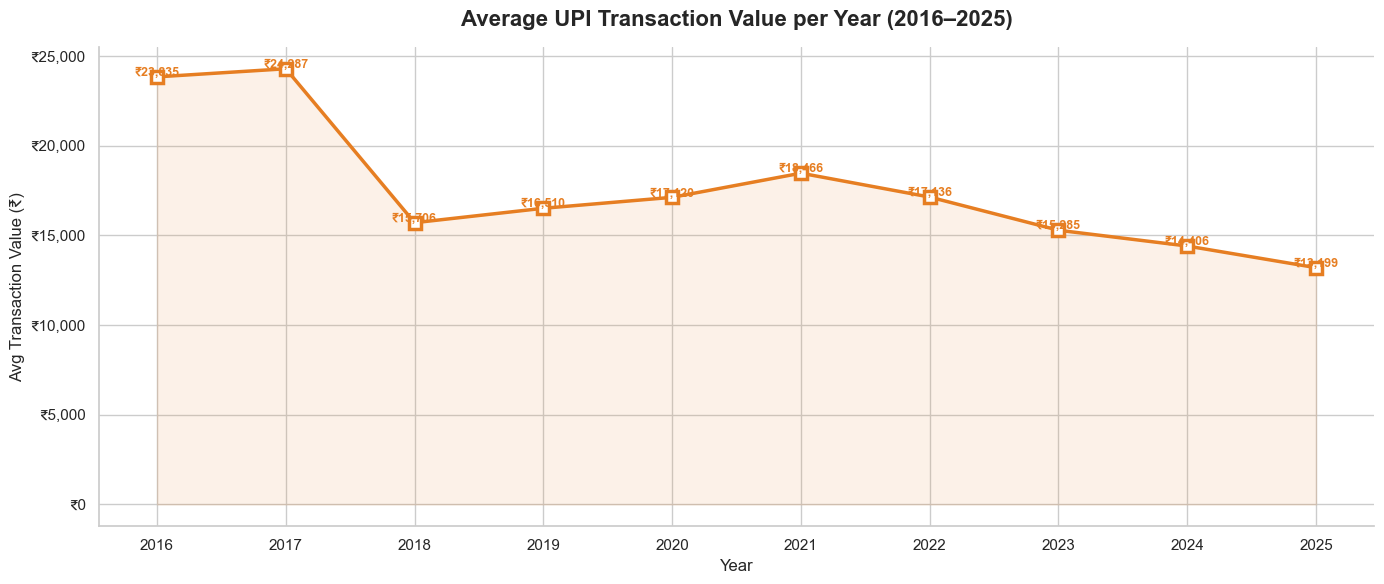

Chart 5 saved


In [9]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(yearly['Year'], yearly['Avg_Txn_Value'],
        color='#e67e22', linewidth=2.5, marker='s',
        markersize=8, markerfacecolor='white', markeredgewidth=2.5)

ax.fill_between(yearly['Year'], yearly['Avg_Txn_Value'],
                alpha=0.1, color='#e67e22')

for _, row in yearly.iterrows():
    ax.text(row['Year'], row['Avg_Txn_Value'] + 50,
            f'₹{row["Avg_Txn_Value"]:,.0f}',
            ha='center', fontsize=9, fontweight='bold', color='#e67e22')

ax.set_title('Average UPI Transaction Value per Year (2016–2025)',
             fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Avg Transaction Value (₹)', fontsize=12)
ax.set_xticks(yearly['Year'])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
sns.despine()
plt.tight_layout()
plt.savefig('../output/chart5_avg_txn_value.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 5 saved")

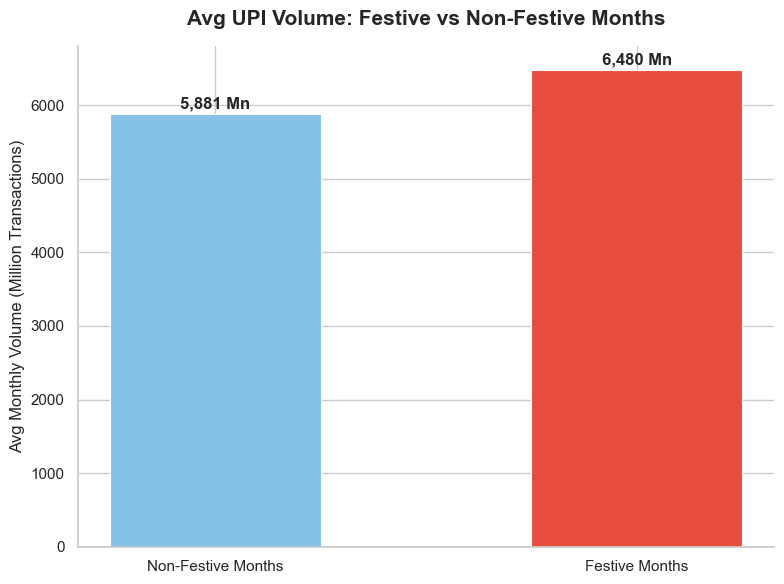

Chart 6 saved


In [10]:
festive_summary = df.groupby('Is_Festive_Season')['Volume_Mn'].mean().reset_index()
festive_summary['Label'] = festive_summary['Is_Festive_Season'].map({0: 'Non-Festive Months', 1: 'Festive Months'})

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(festive_summary['Label'], festive_summary['Volume_Mn'],
              color=['#85c1e9', '#e74c3c'], width=0.5,
              edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, festive_summary['Volume_Mn']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 30,
            f'{val:,.0f} Mn', ha='center', va='bottom',
            fontsize=12, fontweight='bold')

ax.set_title('Avg UPI Volume: Festive vs Non-Festive Months',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('')
ax.set_ylabel('Avg Monthly Volume (Million Transactions)', fontsize=12)
sns.despine()
plt.tight_layout()
plt.savefig('../output/chart6_festive_vs_nonfestive.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 6 saved")

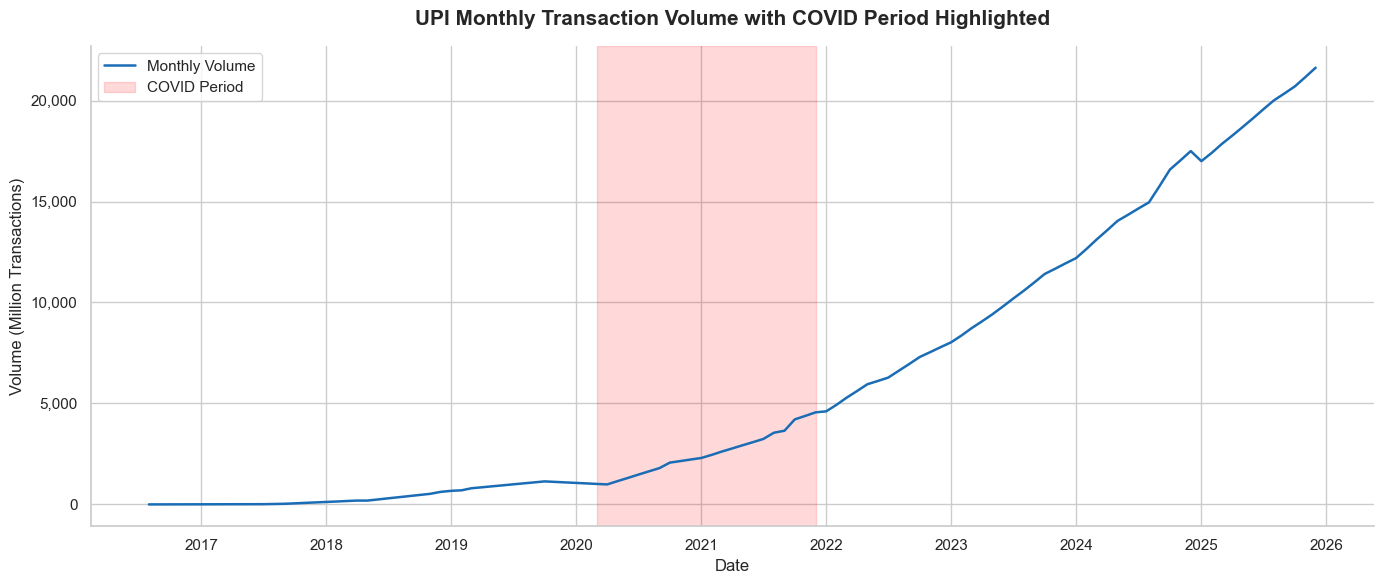

Chart 7 saved


In [11]:
fig, ax = plt.subplots(figsize=(14, 6))

# Plot full line
ax.plot(df['Date'], df['Volume_Mn'], color='#1a6db5',
        linewidth=1.8, label='Monthly Volume')

# Highlight COVID period
covid = df[df['Is_Covid_Period'] == 1]
ax.axvspan(covid['Date'].min(), covid['Date'].max(),
           alpha=0.15, color='red', label='COVID Period')

ax.set_title('UPI Monthly Transaction Volume with COVID Period Highlighted',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Volume (Million Transactions)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.savefig('../output/chart7_covid_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 7 saved")

In [12]:
# Insight 1: Overall growth
first_full_year = yearly[yearly['Year'] == 2017]['Total_Volume_Mn'].values[0]
last_year = yearly[yearly['Year'] == 2025]['Total_Volume_Mn'].values[0]
overall_growth = ((last_year - first_full_year) / first_full_year) * 100

# Insight 2: Highest YoY growth year
max_yoy_row = yearly.dropna(subset=['Volume_YoY_Growth'])
best_year = max_yoy_row.loc[max_yoy_row['Volume_YoY_Growth'].idxmax()]

# Insight 3: Lowest YoY growth year (post maturity)
worst_year = max_yoy_row.loc[max_yoy_row['Volume_YoY_Growth'].idxmin()]

# Insight 4: COVID year behaviour
covid_2020 = yearly[yearly['Year'] == 2020]['Total_Volume_Mn'].values[0]
pre_covid_2019 = yearly[yearly['Year'] == 2019]['Total_Volume_Mn'].values[0]
covid_growth = ((covid_2020 - pre_covid_2019) / pre_covid_2019) * 100

# Insight 5: Festive vs non festive
festive_avg = df[df['Is_Festive_Season'] == 1]['Volume_Mn'].mean()
nonfestive_avg = df[df['Is_Festive_Season'] == 0]['Volume_Mn'].mean()
festive_premium = ((festive_avg - nonfestive_avg) / nonfestive_avg) * 100

# Insight 6: Avg transaction value change
avg_2017 = yearly[yearly['Year'] == 2017]['Avg_Txn_Value'].values[0]
avg_2025 = yearly[yearly['Year'] == 2025]['Avg_Txn_Value'].values[0]
avg_change = ((avg_2025 - avg_2017) / avg_2017) * 100

# Insight 7: Total value in 2025
total_value_2025 = yearly[yearly['Year'] == 2025]['Total_Value_Cr'].values[0]

print("=" * 60)
print("KEY INSIGHTS — UPI GROWTH ANALYSIS")
print("=" * 60)
print(f"\n1. UPI volume grew {overall_growth:,.0f}% from 2017 to 2025")
print(f"   From {first_full_year:,.0f} Mn → {last_year:,.0f} Mn transactions")

print(f"\n2. Highest YoY growth: {best_year['Year']:.0f} at {best_year['Volume_YoY_Growth']:.1f}%")

print(f"\n3. Slowest YoY growth: {worst_year['Year']:.0f} at {worst_year['Volume_YoY_Growth']:.1f}%")
print(f"   (Market maturing — slower % growth is expected at scale)")

print(f"\n4. COVID impact (2020 vs 2019): +{covid_growth:.1f}% growth")
print(f"   UPI did NOT slow during COVID — digital payments accelerated")

print(f"\n5. Festive months average {festive_premium:.1f}% higher volume than non-festive months")

print(f"\n6. Avg transaction value changed {avg_change:.1f}% from 2017 to 2025")
print(f"   ₹{avg_2017:,.0f} → ₹{avg_2025:,.0f} per transaction")

print(f"\n7. Total UPI transaction value in 2025: ₹{total_value_2025/100:.2f} Lakh Crore")
print("=" * 60)

KEY INSIGHTS — UPI GROWTH ANALYSIS

1. UPI volume grew 68,206% from 2017 to 2025
   From 339 Mn → 231,750 Mn transactions

2. Highest YoY growth: 2017 at 3052.7%

3. Slowest YoY growth: 2025 at 31.3%
   (Market maturing — slower % growth is expected at scale)

4. COVID impact (2020 vs 2019): +58.2% growth
   UPI did NOT slow during COVID — digital payments accelerated

5. Festive months average 10.2% higher volume than non-festive months

6. Avg transaction value changed -45.7% from 2017 to 2025
   ₹24,287 → ₹13,199 per transaction

7. Total UPI transaction value in 2025: ₹305330.00 Lakh Crore


In [13]:
# Verify 2025 total value
val_2025 = yearly[yearly['Year'] == 2025]['Total_Value_Cr'].values[0]
print(f"2025 Total Value in Crore: ₹{val_2025:,.0f} Cr")
print(f"In Lakh Crore: ₹{val_2025/100000:.2f} Lakh Crore")
print(f"In Trillion: ₹{val_2025/10000000:.2f} Trillion")

2025 Total Value in Crore: ₹30,533,000 Cr
In Lakh Crore: ₹305.33 Lakh Crore
In Trillion: ₹3.05 Trillion


In [1]:
#SQL
import pandas as pd
import sqlite3

# Load cleaned data into SQLite
df = pd.read_excel('../output/upi_cleaned.xlsx')
yearly = pd.read_excel('../output/upi_yearly_summary.xlsx')

conn = sqlite3.connect('../output/upi_database.db')
df.to_sql('upi_monthly', conn, if_exists='replace', index=False)
yearly.to_sql('upi_yearly', conn, if_exists='replace', index=False)
print("Database created successfully")

Database created successfully


In [2]:
# Query 1 — Year-wise summary
q1 = pd.read_sql_query("""
    SELECT Year,
           ROUND(SUM(Volume_Mn), 2) AS Total_Volume_Mn,
           ROUND(SUM(Value_Cr), 2) AS Total_Value_Cr,
           ROUND(AVG(Avg_Txn_Value), 2) AS Avg_Txn_Value
    FROM upi_monthly
    GROUP BY Year
    ORDER BY Year
""", conn)
print("Query 1 — Year-wise Summary")
print(q1.to_string())

Query 1 — Year-wise Summary
   Year  Total_Volume_Mn  Total_Value_Cr  Avg_Txn_Value
0  2016            10.76         3119.83       23834.62
1  2017           339.28        61519.67       24286.61
2  2018          3744.17       596308.00       15706.09
3  2019         11335.16      1875600.00       16510.16
4  2020         17930.00      3136000.00       17120.50
5  2021         39745.00      7318000.00       18466.11
6  2022         75005.00     12786000.00       17135.61
7  2023        120185.00     18321000.00       15285.05
8  2024        176450.00     25362500.00       14405.50
9  2025        231750.00     30533000.00       13198.80


In [3]:
# Query 2 — Festive vs Non-Festive
q2 = pd.read_sql_query("""
    SELECT 
        CASE WHEN Is_Festive_Season = 1 
             THEN 'Festive Months' 
             ELSE 'Non-Festive Months' END AS Period,
        ROUND(AVG(Volume_Mn), 2) AS Avg_Volume_Mn,
        ROUND(AVG(Value_Cr), 2) AS Avg_Value_Cr,
        COUNT(*) AS Month_Count
    FROM upi_monthly
    GROUP BY Is_Festive_Season
""", conn)
print("Query 2 — Festive vs Non-Festive")
print(q2.to_string())

Query 2 — Festive vs Non-Festive
               Period  Avg_Volume_Mn  Avg_Value_Cr  Month_Count
0  Non-Festive Months        5880.50     869820.36           93
1      Festive Months        6480.37     954987.70           20


In [4]:
# Query 3 — COVID period analysis
q3 = pd.read_sql_query("""
    SELECT Year,
           ROUND(SUM(Volume_Mn), 2) AS Total_Volume,
           ROUND(SUM(Value_Cr), 2) AS Total_Value,
           MAX(CASE WHEN Is_Covid_Period = 1 
               THEN 'COVID Period' 
               ELSE 'Normal Period' END) AS Period_Type
    FROM upi_monthly
    WHERE Year BETWEEN 2018 AND 2022
    GROUP BY Year
    ORDER BY Year
""", conn)
print("Query 3 — COVID Period Analysis")
print(q3.to_string())

Query 3 — COVID Period Analysis
   Year  Total_Volume  Total_Value    Period_Type
0  2018       3744.17     596308.0  Normal Period
1  2019      11335.16    1875600.0  Normal Period
2  2020      17930.00    3136000.0  Normal Period
3  2021      39745.00    7318000.0   COVID Period
4  2022      75005.00   12786000.0  Normal Period


In [5]:
# Query 4 — Top 3 highest volume months ever
q4 = pd.read_sql_query("""
    SELECT Month_Name, Year,
           ROUND(Volume_Mn, 2) AS Volume_Mn,
           ROUND(Value_Cr, 2) AS Value_Cr
    FROM upi_monthly
    ORDER BY Volume_Mn DESC
    LIMIT 10
""", conn)
print("Query 4 — Top 10 Highest Volume Months")
print(q4.to_string())

Query 4 — Top 10 Highest Volume Months
  Month_Name  Year  Volume_Mn    Value_Cr
0   December  2025   21630.00  2797000.00
1   November  2025   21165.00  2762500.00
2    October  2025   20700.00  2728000.00
3  September  2025   20355.00  2606500.00
4     August  2025   20010.00  2485000.00
5       July  2025   19566.67  2494666.67
6       June  2025   19123.33  2504333.33
7        May  2025   18680.00  2514000.00
8      April  2025   18260.00  2472500.00
9      March  2025   17840.00  2431000.00


In [6]:
# Query 5 — Financial year comparison
q5 = pd.read_sql_query("""
    SELECT Financial_Year,
           ROUND(SUM(Volume_Mn), 2) AS Total_Volume_Mn,
           ROUND(AVG(Avg_Txn_Value), 2) AS Avg_Txn_Value,
           COUNT(*) AS Months_Count
    FROM upi_monthly
    GROUP BY Financial_Year
    ORDER BY Financial_Year
""", conn)
print("Query 5 — Financial Year Summary")
print(q5.to_string())

conn.close()
print("\nAll queries executed successfully")

Query 5 — Financial Year Summary
  Financial_Year  Total_Volume_Mn  Avg_Txn_Value  Months_Count
0        FY16-17            29.57       26050.60             8
1        FY17-18           754.00       20451.91            12
2        FY18-19          5482.18       16120.70            12
3        FY19-20         12283.62       16443.55            12
4        FY20-21         22180.00       17854.14            12
5        FY21-22         47210.00       18254.17            12
6        FY22-23         85295.00       16639.56            12
7        FY23-24        133040.00       15047.15            12
8        FY24-25        190730.00       14098.09            12
9        FY25-26        179490.00       13025.57             9

All queries executed successfully
